# Individual homework project 1: Oisín Duke

In [ ]:
#pip install pandas numpy matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [42]:
customers = pd.read_csv("data/customers.csv").drop_duplicates(subset="customer_id")
sessions = pd.read_csv("data/web_sessions.csv").drop_duplicates(subset="session_id")
campaigns = pd.read_csv("data/campaign_touchpoints.csv").drop_duplicates(subset="touchpoint_id")
transactions = pd.read_csv("data/transactions.csv").drop_duplicates(subset="transaction_id")

### Prep

In [ ]:
customers.head(12)
### "customer_information"
sessions.head(12)
###  "visits_to_website"
campaigns.head(12)
### "marketing_campaigns"
transactions.head(5)
### "sales_transactions"

,customer_id,age,gender,country,acquisition_channel,signup_date,customer_status,loyalty_tier,campaign_id,last_active_date
0,1,56.0,Other,Germany,referral,2019-07-21,one_time,none,183,2021-04-06
1,2,38.0,Other,Netherlands,email,2022-03-04,churned,none,548,2024-11-27
2,3,28.0,Other,Australia,referral,2024-05-21,repeat,bronze,37,2025-01-07
3,4,19.0,Female,Australia,paid_search,2022-06-28,repeat,bronze,14,2024-03-20
4,5,38.0,Female,Australia,referral,2024-07-17,one_time,none,635,2024-11-12
5,6,61.0,Other,Germany,paid_search,2022-03-10,one_time,none,595,2023-06-19
6,7,NaN,Other,Australia,email,2019-02-10,one_time,none,159,2019-07-09
7,8,61.0,Male,Germany,referral,2019-03-10,loyal,silver,494,2019-09-11
8,9,68.0,Male,Netherlands,paid_search,2019-05-19,repeat,bronze,329,2020-07-20
9,10,NaN,Female,US,paid_search,2020-03-02,repeat,bronze,614,2022-03-01


#### Columns overview

In [44]:
tables = [customers, sessions, campaigns, transactions]
names = ["customers", "sessions", "campaigns", "transactions"]
for i, table in enumerate(tables):
    print(f"{names[i]:<15}: {table.shape[0]} rows, {table.shape[1]} columns: \n\t {table.columns.tolist()}")

customers      : 10000 rows, 10 columns: 
	 ['customer_id', 'age', 'gender', 'country', 'acquisition_channel', 'signup_date', 'customer_status', 'loyalty_tier', 'campaign_id', 'last_active_date']
sessions       : 70000 rows, 14 columns: 
	 ['session_id', 'customer_id', 'pages_viewed', 'time_on_site', 'device_type', 'traffic_source', 'session_date', 'converted', 'bounce', 'cart_additions', 'checkout_started', 'exit_page', 'browser', 'is_logged_in']
campaigns      : 10000 rows, 6 columns: 
	 ['customer_id', 'campaign_id', 'touchpoint_id', 'touchpoint_date', 'clicked', 'converted']
transactions   : 45000 rows, 9 columns: 
	 ['transaction_id', 'customer_id', 'product_category', 'purchase_value', 'discount_used', 'purchase_date', 'is_refunded', 'refund_date', 'refund_reason']


In [45]:
#Checking the categorical data for errors in categories as seen in acquisition channel "Email" and "email"
for i, table in enumerate(tables):
    print(f"{names[i]}")
    for item in table.columns:
        if len(table[item].unique().tolist()) < 20:
            print(f"\t {item}: {table[item].unique().tolist()}")

customers
	 gender: ['Other', 'Female', 'Male']
	 country: ['Germany', 'Netherlands', 'Australia', 'US', 'France', 'Spain', 'UK', 'Canada']
	 acquisition_channel: ['referral', 'email', 'paid_search', 'social', 'paid_Search', 'organic', 'Email']
	 customer_status: ['one_time', 'churned', 'repeat', 'loyal', 'vip']
	 loyalty_tier: ['none', 'bronze', 'silver', 'gold']
sessions
	 pages_viewed: [8, 5, 4, 3, 2, 6, 7, 1, 9, 10, 11, 13, 12, 15, 14, 16, 17]
	 device_type: ['desktop', 'mobile', 'tablet', nan]
	 traffic_source: ['organic', 'social', 'paid', 'direct', 'email']
	 converted: [0, 1]
	 bounce: [0, 1]
	 cart_additions: [0, 3, 2, 1, 4, 5, 6, 7, 10, 8]
	 checkout_started: [0, 1]
	 exit_page: ['homepage', 'checkout', 'cart', 'product']
	 browser: ['Chrome', 'Safari', 'Firefox', 'Edge']
	 is_logged_in: [1, 0]
campaigns
	 clicked: [1, 0]
	 converted: [0, 1]
transactions
	 product_category: ['home', 'fashion', 'toys', 'electronics', 'sports', 'beauty']
	 discount_used: [0, 1]
	 is_refunded: [

In [46]:
customers.replace("Email", "email", inplace=True)
customers.replace("paid_Search", "paid_search", inplace=True)

print("customers \n", customers.isnull().sum(), " \n \n",  
    "sessions \n", sessions.isnull().sum(), " \n",  
      "campaigns \n", campaigns.isnull().sum(), " \n",  
      "transactions \n", transactions.isnull().sum()
    )
#customer - 807 age col
#sessions 500 device type
#cmpaign none#
#transactions refund date and reason 41368 (80%)

customers 
 customer_id              0
age                    807
gender                   0
country                  0
acquisition_channel      0
signup_date              0
customer_status          0
loyalty_tier             0
campaign_id              0
last_active_date         0
dtype: int64  
 
 sessions 
 session_id            0
customer_id           0
pages_viewed          0
time_on_site          0
device_type         498
traffic_source        0
session_date          0
converted             0
bounce                0
cart_additions        0
checkout_started      0
exit_page             0
browser               0
is_logged_in          0
dtype: int64  
 campaigns 
 customer_id        0
campaign_id        0
touchpoint_id      0
touchpoint_date    0
clicked            0
converted          0
dtype: int64  
 transactions 
 transaction_id          0
customer_id             0
product_category        0
purchase_value          0
discount_used           0
purchase_date           0
is_refunded 

### Specific questions

Q1. What is the average purchase value for customers from Spain?

Note: (I'm going to assume curreny is euro €, using Irish standard format "€ X.XX")

In [47]:
merged = pd.merge(transactions, customers, how='left', on='customer_id')

#merged.columns
avg_by_country = merged.groupby('country')['purchase_value'].mean().sort_values(ascending=False)

print(f"Average purchase value for customers in Spain: € {avg_by_country.loc['Spain']:.2f}")

Average purchase value for customers in Spain: € 230.96


Q2. What is the minimum purchase value for customers from Germany?

In [48]:
min_by_country = merged.groupby('country')['purchase_value'].min()

print(f"Minimum purchase value for customers in Germany: € {min_by_country.loc['Germany']:.2f}")

Minimum purchase value for customers in Germany: € 10.01


In [49]:
#verificaiton
merged.loc[:, ["purchase_value", "country"]].sort_values('purchase_value', ascending=True).head(4)

,purchase_value,country
21954,10.01,UK
17599,10.01,Germany
27404,10.02,UK
3302,10.03,Canada


Q3. How much did males spend on buying products in the Sports category?

In [50]:
merged.columns

totals_gender_category = merged.groupby(['gender', 'product_category'])['purchase_value'].sum()
#print(totals_gender_category)

print(f"Total purchase value for males in the sports category: € {totals_gender_category.loc['Male', 'sports']:,.2f}")

Total purchase value for males in the sports category: € 404,877.87


Q4. What is the average age of female customers from Canada?

In [51]:
age_by_gender_country = merged.groupby(['gender', 'country'])['age'].mean()

print(f"Average age for females in Canada: {age_by_gender_country.loc['Female', 'Canada']:.0f} years")

Average age for females in Canada: 43 years


Q5. How much does an average male customer from the UK spend?

In [52]:
purchase_gender_country = merged.groupby(['gender', 'country'])['purchase_value'].mean()

print(f"Average purchase value for males in the UK: € {purchase_gender_country.loc['Male', 'UK']:.2f}")

Average purchase value for males in the UK: € 234.48


Q6. What is the maximum purchase value for females in the Toys category?

In [53]:
max_gender_category = merged.groupby(['gender', 'product_category'])['purchase_value'].max()
#print(max_gender_category)
print(f"Maximum purchase value for females in the toys category: € {max_gender_category.loc['Female', 'toys']:.2f}")

Maximum purchase value for females in the toys category: € 79.99


In [54]:
#verification 
df_req = merged.loc[:, ['purchase_value','gender','product_category']].sort_values('purchase_value', ascending=False)
df_req[df_req['product_category'] == 'toys'].sort_values('purchase_value', ascending=False).head(5)

,purchase_value,gender,product_category
22297,79.99,Female,toys
2300,79.99,Female,toys
29980,79.98,Male,toys
26191,79.97,Male,toys
7928,79.97,Female,toys


Q7. What is the average number of pages viewed for customers who made a purchase (converted)?

In [55]:
# Assuming this means the average number of pages viewed for a customer who made a purchase in that session.
purchase_made = sessions[sessions['converted'] == 1]
session_pageviews_avg = purchase_made['pages_viewed'].mean()

print(f"Avg pageviews for customers who made a purchase that session: {session_pageviews_avg:.2f}")

Avg pageviews for customers who made a purchase that session: 5.73


In [56]:
#Assuming this means the avg for customer who ever made a purchase, in that session or not:
customerid_converted = sessions[sessions['converted'] == 1]['customer_id'].unique().tolist()

pagevies_avg = sessions[sessions['customer_id'].isin(customerid_converted)]['pages_viewed'].mean()

print(f"Avg pageviews for customers who ever made a purchase: {pagevies_avg:.2f}")

Avg pageviews for customers who ever made a purchase: 5.05


Q8. What is the average time spent on the site for purchasing vs non-purchasing customers?

In [57]:
#sessions.columns

In [58]:
purchasing = sessions[sessions['converted'] == 1]
non_purchasing = sessions[sessions['converted'] == 0]

def timespent(df):
    return df['time_on_site'].mean(), (df['time_on_site'].mean()/60)

print(f"""
      Time spent on site analysis:
      {"Purchasing customers:":<30} {timespent(purchasing)[0]:.2f} seconds ({timespent(purchasing)[1]:.2f} minutes)
      {"Non-purchasing customers:":<30} {timespent(non_purchasing)[0]:.2f} seconds ({timespent(non_purchasing)[1]:.2f} minutes)
      """
      )



      Time spent on site analysis:
      Purchasing customers:          311.16 seconds (5.19 minutes)
      Non-purchasing customers:      299.24 seconds (4.99 minutes)
      


### Visualisation tasks

Q9. Plot purchasing value across years.

In [59]:
dates = pd.to_datetime(transactions['purchase_date'])
years = dates.dt.year
purchase_values_year = transactions['purchase_value'].groupby(years).sum()

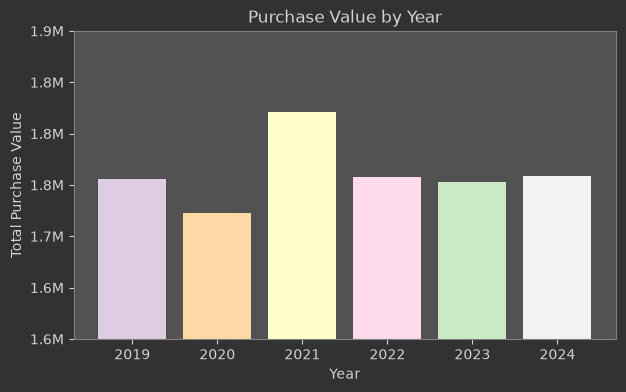

In [60]:
fig, ax = plt.subplots(figsize=(7, 4))
colours = plt.colormaps['Pastel1'](np.linspace(0.3,0.9, len(years.unique())))
ax.bar(years.unique(), purchase_values_year, color=colours)

fig.patch.set_facecolor("#323232")
ax.set_facecolor("#525252")
ax.tick_params(colors='lightgray')

for spine in ax.spines.values():
    spine.set_color("#808080")

    

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M'))

plt.xlabel("Year", color="lightgray")
plt.ylabel("Total Purchase Value", color="lightgray")

ax.set_ylim(1600000, 1900000)

ax.set_title("Purchase Value by Year", color="lightgray")
plt.show()

Q10. Plot purchasing value across product categories.

In [61]:
purchases_catoegory = merged.groupby('product_category')['purchase_value'].sum().sort_values(ascending=False)
categories = merged['product_category'].unique()

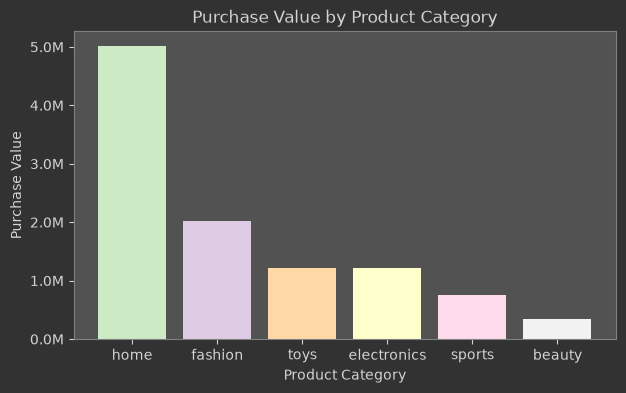

In [62]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(categories, purchases_catoegory, color=colours)

fig.patch.set_facecolor("#323232")
ax.set_facecolor("#525252")
ax.tick_params(colors='lightgray')

for spine in ax.spines.values():
    spine.set_color("#808080")

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M'))

plt.xlabel("Product Category", color="lightgray")
plt.ylabel("Purchase Value", color="lightgray")

plt.title("Purchase Value by Product Category", color="lightgray")
plt.show()


### Free exercise

Explore the transactions dataset and:

- Create two visualisations of your choice
- Identify three patterns in the data
- Write five insights in plain English explaining what the data tells us

Your insights should focus on behaviour, spending patterns, or conversion

<Axes: xlabel='country', ylabel='purchase_value'>

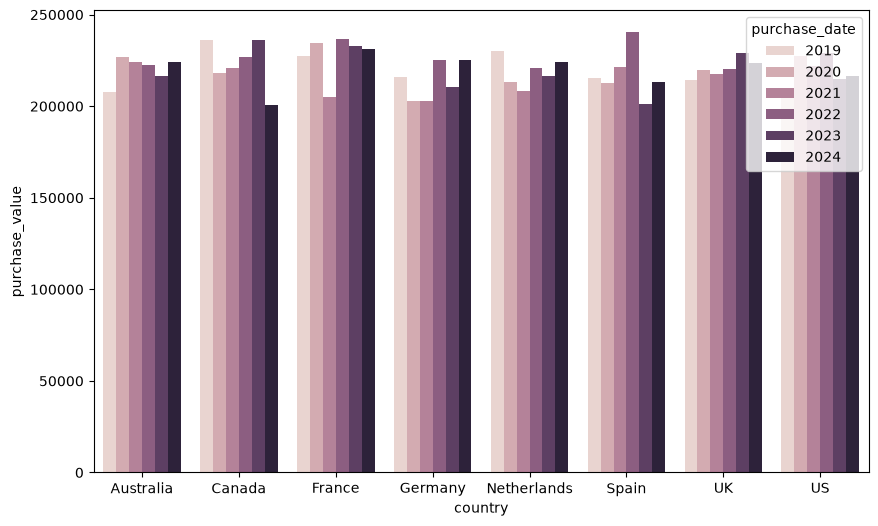

In [108]:
country_years = merged.groupby(['country', years])['purchase_value'].sum().reset_index()
country_years

plt.figure(figsize=(10,6))
sns.barplot(data=country_years, x="country", y="purchase_value", hue='purchase_date')

#### Pattern: 
Spending is almost the same across all countries, and is not going up over the years.

In [64]:
merged.columns

Index(['transaction_id', 'customer_id', 'product_category', 'purchase_value',
       'discount_used', 'purchase_date', 'is_refunded', 'refund_date',
       'refund_reason', 'age', 'gender', 'country', 'acquisition_channel',
       'signup_date', 'customer_status', 'loyalty_tier', 'campaign_id',
       'last_active_date'],
      dtype='str')

In [65]:
refunds_category = merged.groupby('product_category')['is_refunded'].sum().sort_values(ascending=False)
categories = merged['product_category'].unique()

In [66]:
refunds_reasons = merged.groupby('refund_reason')['is_refunded'].sum().sort_values(ascending=False)
refunds_reasons

refund_reason
late_delivery    923
wrong_item       917
damaged          909
changed_mind     883
Name: is_refunded, dtype: int64

In [67]:
merged.groupby(['refund_reason', years])['is_refunded'].sum()

refund_reason  purchase_date
changed_mind   2019             128
               2020             138
               2021             146
               2022             143
               2023             163
               2024             165
damaged        2019             168
               2020             155
               2021             152
               2022             144
               2023             154
               2024             136
late_delivery  2019             135
               2020             149
               2021             157
               2022             159
               2023             160
               2024             163
wrong_item     2019             143
               2020             177
               2021             151
               2022             133
               2023             156
               2024             157
Name: is_refunded, dtype: int64

#### Pattern:
Refunds due todDamages have been going down slightly over time, late deliveries going up. Changed mind refunds are going up as well.

##### Insight: 
We can see above the totals for each refund reason, We should look into this with the product team to see if some of these can be addressed, in particular the late deliveries, wrong items and damage. It looks like returns from damages have gone down year over year but returns from late deliveries have gone up, We should check if there have been any changes in the storage/warehouse and in the deliveries company we use, to see if this is related to changes, or if it could be actioned. Lets see how these refunds compare in each category:

In [68]:
refunds_sales_category = merged.groupby('product_category').agg(
    is_refunded=('is_refunded', 'sum'),
    transaction_id=('transaction_id', 'count')
    ).sort_values(by='is_refunded', ascending=False)
refunds_sales_category["refund_%"] = (refunds_sales_category['is_refunded'] / refunds_sales_category['transaction_id'])*100
refunds_sales_category

,is_refunded,transaction_id,refund_%
product_category,,,
home,640,7488,8.547009
fashion,624,7581,8.231104
electronics,612,7424,8.243534
beauty,600,7586,7.909307
sports,585,7504,7.795842
toys,571,7417,7.698530


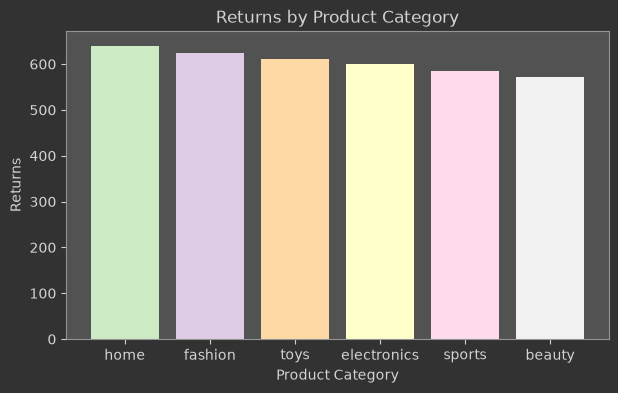

In [69]:
fig, ax = plt.subplots(figsize=(7, 4))

colours = plt.colormaps['Pastel1'](np.linspace(0.3,0.9, len(categories)))
fig.patch.set_facecolor("#323232")
ax.set_facecolor("#525252")

ax.bar(categories, refunds_sales_category['is_refunded'], color=colours)

#ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M'))
#ax.set_yscale('log')

plt.xlabel("Product Category", color="lightgray")
plt.ylabel("Returns", color="lightgray")
ax.tick_params(colors='lightgray')

plt.title("Returns by Product Category", color="lightgray")

for spine in ax.spines.values():
    spine.set_color("#949494")
plt.show()

##### Insight: 
We see some variation in the return/refund rate by product category, and it follows what you might expect; the typically higher priced items have a higher rate, customer would be more likely to pursue a refund on higher priced items. Home fashion and electronics may be higher priced per item than beaty, sports or toys. Although when we check the purchase values we dont see this below, electronics and home are higher but fashion is not. 
This is explained by fashion being more likely not to fit the buyer and so being returned more often, we can check that below, lets also check out toys, which has the lowest return rate.
A reccomendation I might make based on these, if a manager was looking to lower the return rate, would be to push sports and beauty items, as they have lower return rates but still have a higher per item purchase value, toys having a low refund rate and low cost follows what you'd expect as does home and electronics having high costs and higer refund rates (resulting in higher total refunds paid out).


In [70]:
merged.groupby('product_category')['purchase_value'].mean().sort_values(ascending=False)

product_category
electronics    676.210686
home           270.111830
sports         161.364832
beauty         160.679967
fashion        100.246156
toys            45.430863
Name: purchase_value, dtype: float64

In [71]:
merged[merged['product_category'] == 'toys'].groupby('refund_reason')['is_refunded'].sum()

refund_reason
changed_mind     147
damaged          133
late_delivery    155
wrong_item       136
Name: is_refunded, dtype: int64

In [72]:
merged[merged['product_category'] == 'fashion'].groupby('refund_reason')['is_refunded'].sum()

refund_reason
changed_mind     137
damaged          144
late_delivery    159
wrong_item       184
Name: is_refunded, dtype: int64

#### Insight:
The refund reasons for the categories does not really follow the logic i presented above, fashion being returned for not being the right size should have a refund reason of changed_mind, but compared to the reasons of toys above, its not higher, its the lowest reason proportionally. I don't know why this might be, the reasons given by customers might not be reliable, this is probablyself reported data. Might be that wrong_item is used for wrong sizes, as it is a large proportion of the total, but its not clear.
Let's look into why the wrong item is being sent out so much, maybe the system id's are mixed up, or the warehouse isnt organised properly, we could reccomend updating the shipping checklist. If the issue is on the shipping company's side lets raise that with them and see if there are alternatives. 


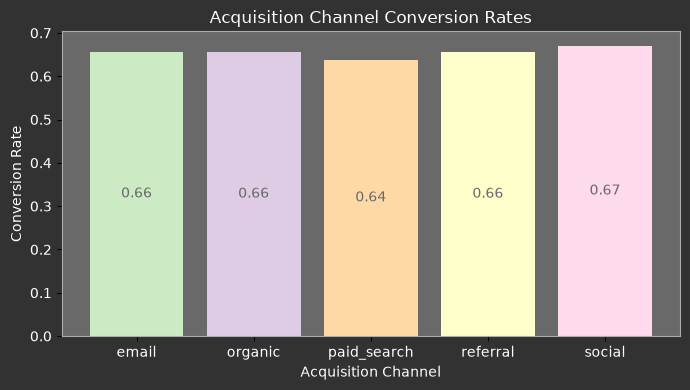

In [73]:
merged_sessions= pd.merge(sessions, customers, how='left', on='customer_id')


df1 = merged_sessions.groupby('acquisition_channel')['customer_id'].size()
df2 = merged_sessions[merged_sessions['customer_id'].isin(customerid_converted)].groupby('acquisition_channel')['customer_id'].size()

aquisition_comparison = pd.concat([df1, df2], axis=1, keys=['All Customers', 'Converted Customers'])

#(df2/df1).plot(kind='bar', figsize=(10, 6), color=["#EB7B20FF", "#23A1F6"])

fig, ax = plt.subplots(figsize=(7, 4))

colours = plt.colormaps['Pastel1'](np.linspace(0.3,0.9, len(categories)))
fig.patch.set_facecolor("#323232")
ax.set_facecolor("#696969")

ax.bar((df2/df1).index, (df2/df1).values, color=colours, label="Conversion Rate")
ax.bar_label(ax.containers[0], fmt="%.2f", color="#696969", label_type="center")

plt.title("Acquisition Channel Conversion Rates", color="white")
plt.xlabel("Acquisition Channel", color="white")
plt.ylabel("Conversion Rate", color="white")
plt.xticks(rotation=0, color="white")
plt.yticks(color="white")
plt.tight_layout()

for spine in ax.spines.values():
    spine.set_color("#ADADAD")

plt.show()


#### Insights:

I want to ask the marking team what paid search is, because if we are paying surely the conversion rate should be better than other sources, even looking at the number of sessions, we are getting the same from paid search than any other. I dont have any further information on what this is so I'm working with a limited view here. 

Either way, conversion rates are very very high which is great from quick searched online I'm seeing an average of of 3-4%, so we are doing really well here.

In [74]:
sessions['traffic_source'].value_counts()

traffic_source
paid       14083
organic    14071
email      14053
direct     14027
social     13766
Name: count, dtype: int64

In [87]:
value_by_type = merged.groupby('customer_status')['purchase_value'].sum()
value_by_type

customer_status
churned      498042.92
loyal       1536074.13
one_time    4301451.22
repeat      3743292.00
vip          490651.99
Name: purchase_value, dtype: float64

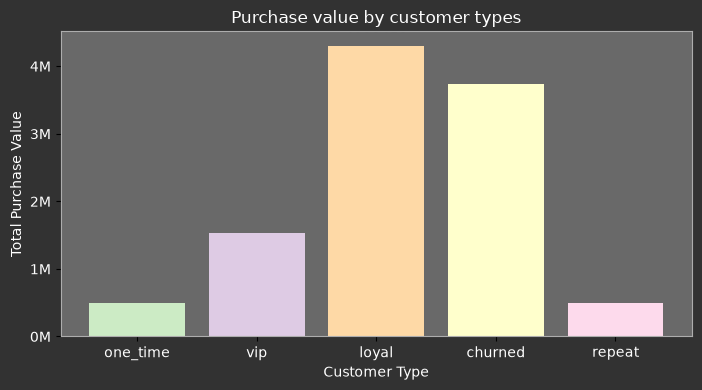

In [96]:
value_by_type = merged.groupby('customer_status')['purchase_value'].sum()

fig, ax = plt.subplots(figsize=(7, 4))

colours = plt.colormaps['Pastel1'](np.linspace(0.3,0.9, len(categories)))
fig.patch.set_facecolor("#323232")
ax.set_facecolor("#696969")

ax.bar(merged['customer_status'].unique(), value_by_type, color=colours, label="Conversion Rate")
ax.bar_label(ax.containers[0], fmt="%.0f", color="#696969", )

plt.title("Purchase value by customer types", color="white")
plt.xlabel("Customer Type", color="white")
plt.ylabel("Total Purchase Value", color="white")
plt.xticks(rotation=0, color="white")
plt.yticks(color="white")
plt.tight_layout()

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M'))

for spine in ax.spines.values():
    spine.set_color("#ADADAD")

plt.show()

#### Pattern:
Repeate customers (incl. loyal, vip, churned) generate much more purchases than one time customers.

#### Insight:
We can see that loyal and churned customers, represent the majority of total revenue, with one time customers being a minority. This makes our existing customer information valuable, as we can use the existing records to focus our marketing efforts on existing customers. We could also look into reducing customer churn to try and retain existing customers.